# SHAP Analysis — Diabetes Risk Model

This notebook runs SHAP explainability analysis on trained diabetes risk models (Decision Tree, Random Forest, XGBoost).  
It produces:
- **Summary plot** — beeswarm of SHAP values across the evaluation set
- **Bar plot** — mean |SHAP| feature importance
- **Waterfall plot** — local explanation for a single prediction
- **Feature importance CSV** — exportable ranking table

## 1. Imports & Configuration

In [1]:
from __future__ import annotations

import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

shap.initjs()  # enables inline JS plots in Jupyter

In [ ]:
# ── Path configuration ──────────────────────────────────────────────────────
PROJECT_ROOT = Path(".").resolve().parents[0]
DATA_DIR      = PROJECT_ROOT / "data"
ARTIFACTS_DIR = PROJECT_ROOT / "artifacts"
MODELS_DIR    = ARTIFACTS_DIR / "models"
ASSETS_DIR    = PROJECT_ROOT / "assets"

ASSETS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ── Model registry ──────────────────────────────────────────────────────────
MODEL_FILES = {
    "decision_tree": "decision_tree.pkl",
    "random_forest": "random_forest.pkl",
    "xgboost":       "xgboost.pkl",
}
MODEL_LABELS = {
    "decision_tree": "DecisionTree",
    "random_forest": "RandomForest",
    "xgboost":       "XGBoost",
}

# ── Run parameters (edit here) ───────────────────────────────────────────────
MODEL_NAME       = "decision_tree"   # "decision_tree" | "random_forest" | "xgboost"
BACKGROUND_SIZE  = 500         # rows from X_train used as SHAP background
EVALUATION_SIZE  = 1000        # rows from X_test to explain
MAX_DISPLAY      = 15          # max features shown in plots
RANDOM_STATE     = 42
WATERFALL_INDEX  = 0           # which evaluation row to use for the local plot
SKIP_WATERFALL   = False

MODEL_LABEL = MODEL_LABELS[MODEL_NAME]
print(f"Model selected: {MODEL_LABEL}")

Model selected: XGBoost


## 2. Helper Functions

In [4]:
def require_file(path: Path) -> Path:
    if not path.exists():
        raise FileNotFoundError(
            f"Missing: {path}. Run prepare_data.py, preprocess_data.py, and train_models.py first."
        )
    return path


def load_pickle(path: Path):
    with path.open("rb") as f:
        return pickle.load(f)


def sample_frame(df: pd.DataFrame, n: int, seed: int) -> pd.DataFrame:
    if n <= 0 or n >= len(df):
        return df.copy()
    return df.sample(n=n, random_state=seed).copy()


def compute_shap_values(explainer, X_eval: pd.DataFrame):
    """Return (values, base_values) for any supported SHAP explainer."""
    try:
        explanation  = explainer(X_eval, check_additivity=False)
        values       = np.asarray(explanation.values)
        base_values  = np.asarray(explanation.base_values)
    except TypeError:
        legacy = explainer.shap_values(X_eval, check_additivity=False)
        values = np.stack(legacy, axis=-1) if isinstance(legacy, list) else np.asarray(legacy)
        base_values = np.asarray(explainer.expected_value)

    if values.ndim not in (2, 3):
        raise ValueError(f"Unsupported SHAP output shape: {values.shape}")
    return values, base_values


def predicted_class_matrix(values: np.ndarray, predictions: np.ndarray) -> np.ndarray:
    """Collapse 3-D SHAP values to 2-D using the predicted class per row."""
    if values.ndim == 2:
        return values
    projected = np.empty((values.shape[0], values.shape[1]), dtype=float)
    for i, cls in enumerate(predictions.astype(int)):
        projected[i] = values[i, :, cls]
    return projected


def build_feature_importance(
    values: np.ndarray,
    projected: np.ndarray,
    feature_names: list[str],
    class_names: np.ndarray,
) -> pd.DataFrame:
    data = {
        "feature": feature_names,
        "mean_abs_shap_predicted_class": np.abs(projected).mean(axis=0),
    }
    if values.ndim == 3:
        data["mean_abs_shap_all_classes"] = np.abs(values).mean(axis=(0, 2))
        for i, name in enumerate(class_names):
            data[f"mean_abs_shap_{name}"] = np.abs(values[:, :, i]).mean(axis=0)
    else:
        data["mean_abs_shap_all_classes"] = np.abs(values).mean(axis=0)
    return pd.DataFrame(data).sort_values("mean_abs_shap_predicted_class", ascending=False)


def resolve_base_value(base_values: np.ndarray, sample_idx: int, class_idx: int) -> float:
    if np.isscalar(base_values) or base_values.ndim == 0:
        return float(base_values)
    if base_values.ndim == 1:
        return float(base_values[class_idx] if len(base_values) > class_idx else base_values[sample_idx])
    if base_values.ndim == 2:
        return float(base_values[sample_idx, class_idx])
    raise ValueError(f"Unsupported base_values shape: {base_values.shape}")


print("Helper functions loaded.")

Helper functions loaded.


## 3. Load Data & Model

In [5]:
model          = load_pickle(require_file(MODELS_DIR / MODEL_FILES[MODEL_NAME]))
target_encoder = load_pickle(require_file(ARTIFACTS_DIR / "target_encoder.pkl"))
X_train        = pd.read_csv(require_file(DATA_DIR / "X_train.csv"))
X_test         = pd.read_csv(require_file(DATA_DIR / "X_test.csv"))

print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")
print(f"Features      : {X_train.columns.tolist()}")
print(f"Classes       : {target_encoder.classes_.tolist()}")

X_train shape : (77837, 28)
X_test  shape : (19460, 28)
Features      : ['Age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'glucose_fasting', 'glucose_postprandial', 'insulin_level', 'hba1c', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'education_level', 'income_level', 'gender', 'ethnicity', 'employment_status', 'smoking_status']
Classes       : ['Gestational', 'No Diabetes', 'Pre-Diabetes', 'Type 1', 'Type 2']


## 4. Sample Background & Evaluation Sets

In [7]:
background = sample_frame(X_train, BACKGROUND_SIZE, RANDOM_STATE)
X_eval     = sample_frame(X_test,  EVALUATION_SIZE, RANDOM_STATE)

print(f"Background rows : {len(background)}")
print(f"Evaluation rows : {len(X_eval)}")

Background rows : 500
Evaluation rows : 1000


## 5. Compute SHAP Values

In [8]:
explainer       = shap.TreeExplainer(model, data=background)
values, base_values = compute_shap_values(explainer, X_eval)

predictions     = np.asarray(model.predict(X_eval)).astype(int)
projected       = predicted_class_matrix(values, predictions)
class_names     = np.asarray(target_encoder.classes_)

print(f"SHAP values shape     : {values.shape}")
print(f"Projected shape       : {projected.shape}")
print(f"Base values shape     : {np.asarray(base_values).shape}")
print(f"Unique predictions    : {np.unique(predictions)}")

100%|===================| 4983/5000 [01:50<00:00]        

SHAP values shape     : (1000, 28, 5)
Projected shape       : (1000, 28)
Base values shape     : (1000, 5)
Unique predictions    : [0 1 2 3 4]


## 6. Feature Importance Table

In [9]:
importance_df = build_feature_importance(values, projected, X_eval.columns.tolist(), class_names)

# Save CSV
csv_path = DATA_DIR / f"{MODEL_NAME}_shap_feature_importance.csv"
importance_df.to_csv(csv_path, index=False)
print(f"Saved: {csv_path}")

# Display top features
importance_df.head(MAX_DISPLAY).style \
    .background_gradient(subset=["mean_abs_shap_predicted_class"], cmap="Blues") \
    .format({col: "{:.4f}" for col in importance_df.columns if col != "feature"})

Saved: C:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\MLG382-Diabetes-DSS\data\xgboost_shap_feature_importance.csv


,feature,mean_abs_shap_predicted_class,mean_abs_shap_all_classes,mean_abs_shap_Gestational,mean_abs_shap_No Diabetes,mean_abs_shap_Pre-Diabetes,mean_abs_shap_Type 1,mean_abs_shap_Type 2
18,hba1c,2.6973,1.2973,0.0851,1.3658,3.5200,0.0508,1.4647
15,glucose_fasting,0.8297,0.4873,0.0332,1.2174,0.8388,0.0427,0.3043
0,Age,0.4155,0.6386,1.3466,0.0195,0.0980,1.2309,0.4983
16,glucose_postprandial,0.2125,0.1382,0.0389,0.1983,0.1961,0.0534,0.2043
24,gender,0.1425,0.3608,1.6154,0.0041,0.0329,0.0425,0.1090
19,family_history_diabetes,0.1259,0.0764,0.0046,0.0614,0.0169,0.0706,0.2284
20,hypertension_history,0.1047,0.0731,0.1028,0.0177,0.0166,0.0675,0.1612
8,systolic_bp,0.0896,0.0909,0.0378,0.0087,0.0429,0.2668,0.0981
23,income_level,0.0865,0.0834,0.0179,0.0111,0.0263,0.2617,0.0999
4,sleep_hours_per_day,0.0860,0.0552,0.0335,0.0105,0.0215,0.0937,0.1167


## 7. SHAP Summary Plot (Beeswarm)

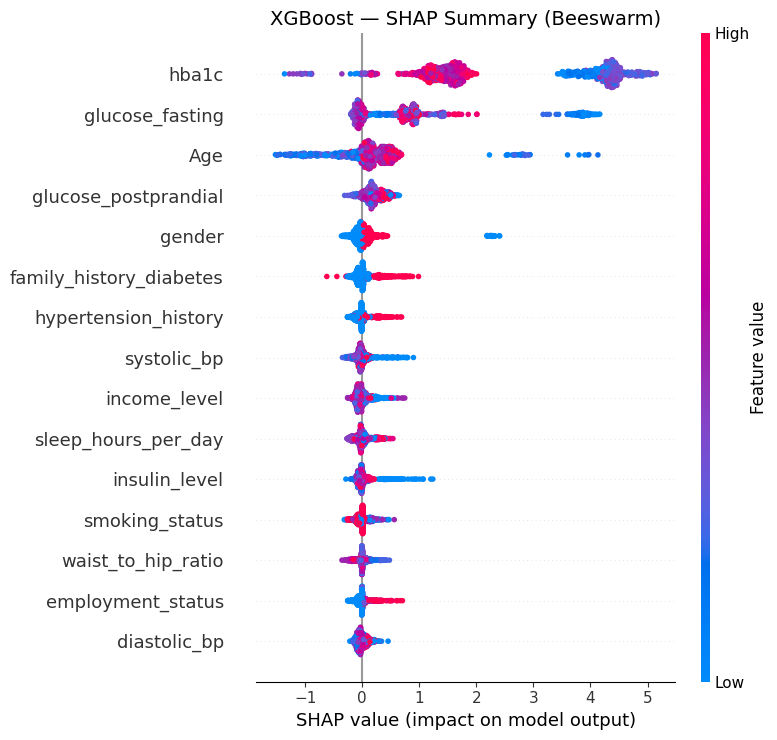

Saved: C:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\MLG382-Diabetes-DSS\assets\XGBoost_shap_summary.png


In [10]:
summary_path = ASSETS_DIR / f"{MODEL_LABEL}_shap_summary.png"

plt.figure(figsize=(10, 8))
shap.summary_plot(projected, X_eval, plot_type="dot", max_display=MAX_DISPLAY, show=False)
plt.title(f"{MODEL_LABEL} — SHAP Summary (Beeswarm)", fontsize=14)
plt.tight_layout()
plt.savefig(summary_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {summary_path}")

**Reading the beeswarm:** Each dot is one sample. Position on the x-axis shows the SHAP value (impact on model output). Colour shows feature value (red = high, blue = low).

## 8. SHAP Bar Plot (Global Importance)

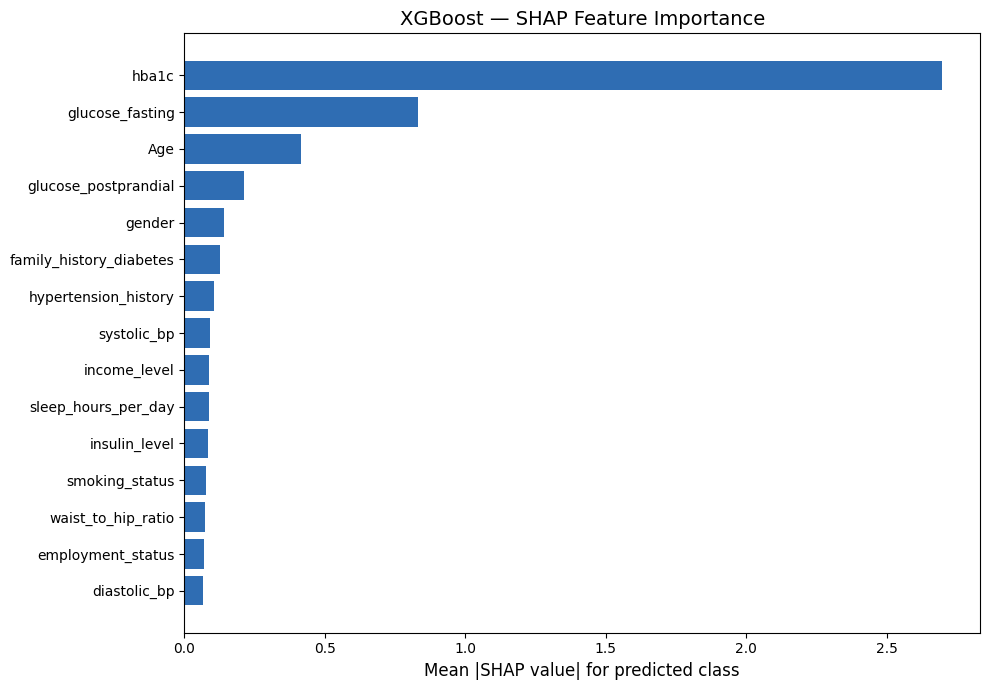

Saved: C:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\MLG382-Diabetes-DSS\assets\XGBoost_shap_bar.png


In [11]:
bar_path    = ASSETS_DIR / f"{MODEL_LABEL}_shap_bar.png"
top_feats   = importance_df.head(MAX_DISPLAY).iloc[::-1]  # reverse for horizontal bar

plt.figure(figsize=(10, 7))
plt.barh(top_feats["feature"], top_feats["mean_abs_shap_predicted_class"], color="#2f6db3")
plt.xlabel("Mean |SHAP value| for predicted class", fontsize=12)
plt.title(f"{MODEL_LABEL} — SHAP Feature Importance", fontsize=14)
plt.tight_layout()
plt.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {bar_path}")

## 9. SHAP Waterfall Plot (Local Explanation)

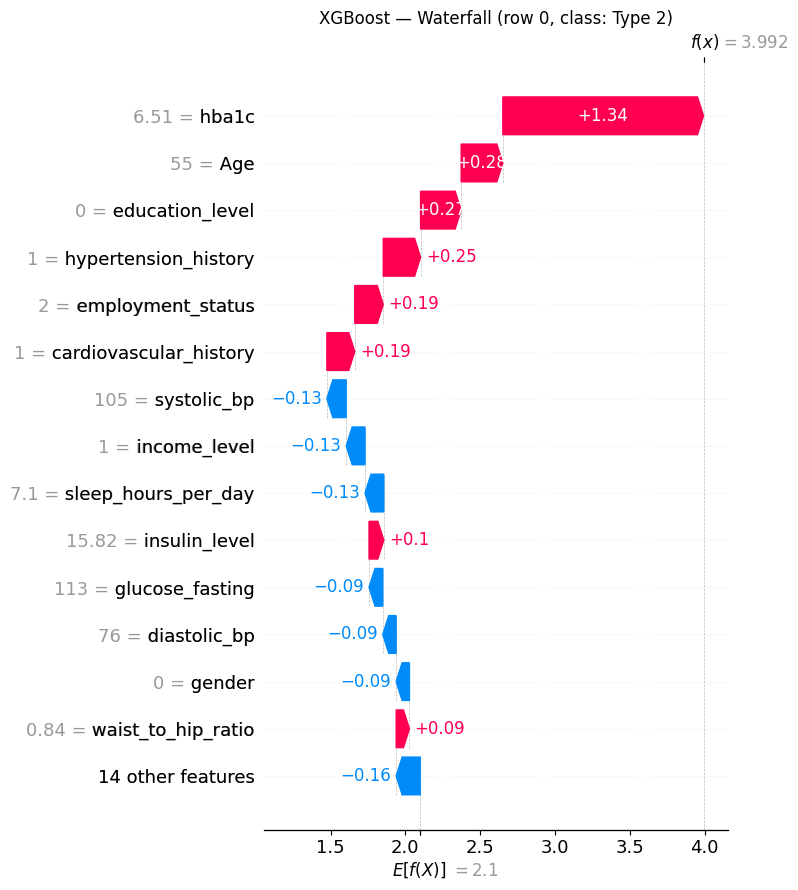

Saved: C:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\MLG382-Diabetes-DSS\assets\XGBoost_shap_waterfall.png
Sample feature values:
                                     value
Age                                  55.00
alcohol_consumption_per_week          1.00
physical_activity_minutes_per_week   45.00
diet_score                            7.80
sleep_hours_per_day                   7.10
screen_time_hours_per_day             1.70
bmi                                  26.20
waist_to_hip_ratio                    0.84
systolic_bp                         105.00
diastolic_bp                         76.00
heart_rate                           69.00
cholesterol_total                   182.00
hdl_cholesterol                      47.00
ldl_cholesterol                     114.00
triglycerides                       145.00
glucose_fasting                     113.00
glucose_postprandial                159.00
insulin_level                        15.82
hba1c                    

In [12]:
if SKIP_WATERFALL:
    print("Waterfall plot skipped (SKIP_WATERFALL=True).")
else:
    idx = max(0, min(WATERFALL_INDEX, len(X_eval) - 1))

    if values.ndim == 3:
        cls_idx      = int(predictions[idx])
        sample_vals  = values[idx, :, cls_idx]
        base_val     = resolve_base_value(base_values, idx, cls_idx)
        cls_label    = class_names[cls_idx]
    else:
        cls_idx      = int(predictions[idx]) if len(class_names) > 1 else 0
        sample_vals  = values[idx]
        base_val     = resolve_base_value(base_values, idx, cls_idx)
        cls_label    = class_names[cls_idx] if len(class_names) > cls_idx else "prediction"

    explanation = shap.Explanation(
        values       = sample_vals,
        base_values  = base_val,
        data         = X_eval.iloc[idx].to_numpy(),
        feature_names= X_eval.columns.tolist(),
    )

    waterfall_path = ASSETS_DIR / f"{MODEL_LABEL}_shap_waterfall.png"

    plt.figure(figsize=(10, 6))
    shap.plots.waterfall(explanation, max_display=MAX_DISPLAY, show=False)
    plt.title(f"{MODEL_LABEL} — Waterfall (row {idx}, class: {cls_label})", fontsize=12)
    plt.tight_layout()
    plt.savefig(waterfall_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {waterfall_path}")
    print(f"Sample feature values:\n{X_eval.iloc[idx].to_frame('value')}")

**Reading the waterfall:** Starting from the base value (E[f(x)]), each bar shows how much a feature pushes the prediction up (red) or down (blue). The final value at the top is f(x) for this sample.

## 10. (Optional) Per-Class SHAP Bar Charts

Only runs when the model produces multi-class SHAP values (3-D array).

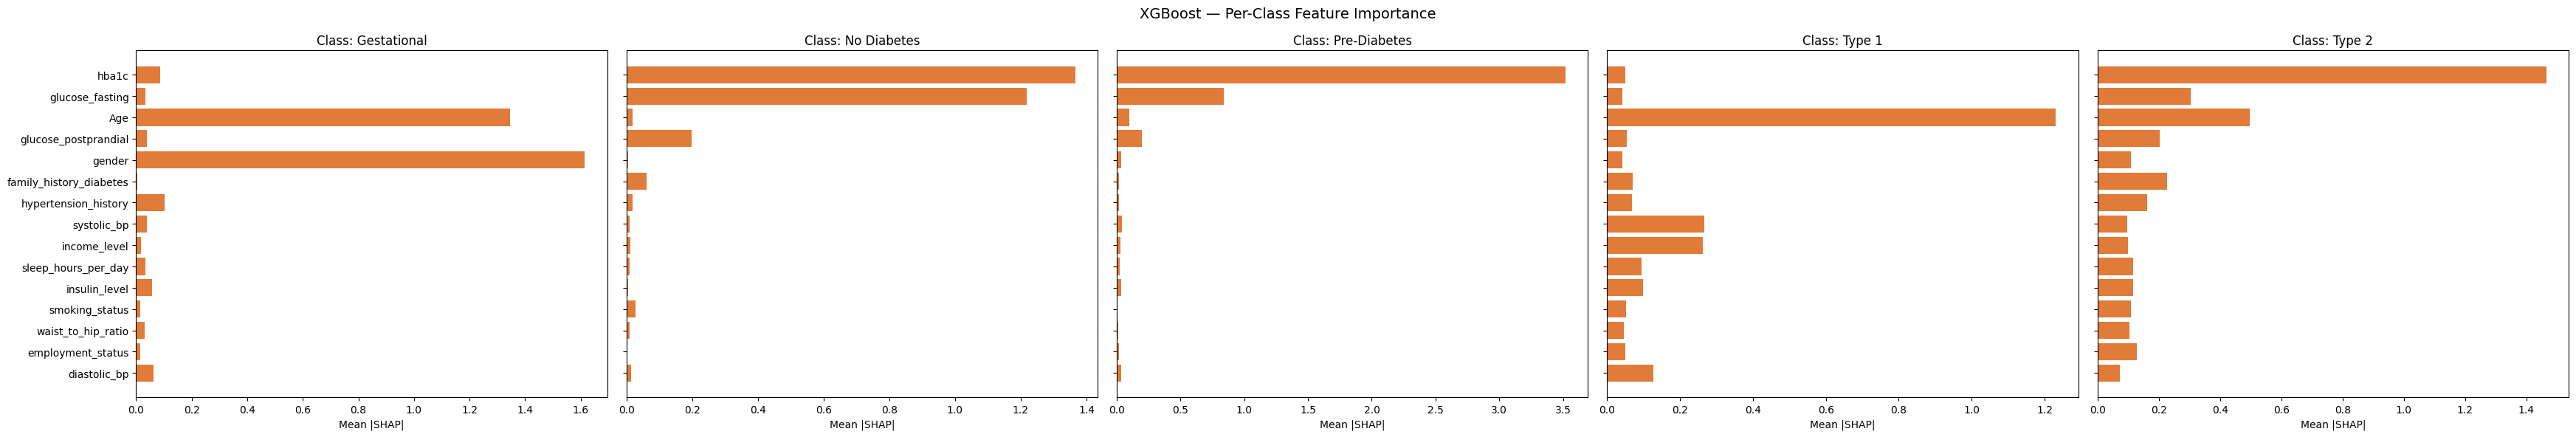

In [13]:
if values.ndim == 3:
    per_class_cols = [c for c in importance_df.columns if c.startswith("mean_abs_shap_") and c not in
                      ("mean_abs_shap_predicted_class", "mean_abs_shap_all_classes")]

    n_classes = len(per_class_cols)
    fig, axes = plt.subplots(1, n_classes, figsize=(7 * n_classes, 6), sharey=True)
    if n_classes == 1:
        axes = [axes]

    for ax, col in zip(axes, per_class_cols):
        top = importance_df[["feature", col]].head(MAX_DISPLAY).iloc[::-1]
        ax.barh(top["feature"], top[col], color="#e07b39")
        ax.set_title(col.replace("mean_abs_shap_", "Class: "), fontsize=12)
        ax.set_xlabel("Mean |SHAP|")

    fig.suptitle(f"{MODEL_LABEL} — Per-Class Feature Importance", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print("Model outputs binary/regression SHAP values — per-class breakdown not applicable.")

## 11. Summary

In [14]:
print("=" * 55)
print(f"  Model analysed  : {MODEL_NAME}")
print(f"  Background rows : {len(background)}")
print(f"  Evaluation rows : {len(X_eval)}")
print(f"  SHAP value shape: {values.shape}")
print("-" * 55)
print(f"  Top {min(5, MAX_DISPLAY)} features by mean |SHAP| (predicted class):")
for _, row in importance_df.head(5).iterrows():
    print(f"    {row['feature']:<35} {row['mean_abs_shap_predicted_class']:.4f}")
print("-" * 55)
print(f"  Outputs saved to : {ASSETS_DIR}")
print(f"  CSV saved to     : {csv_path}")
print("=" * 55)

  Model analysed  : xgboost
  Background rows : 500
  Evaluation rows : 1000
  SHAP value shape: (1000, 28, 5)
-------------------------------------------------------
  Top 5 features by mean |SHAP| (predicted class):
    hba1c                               2.6973
    glucose_fasting                     0.8297
    Age                                 0.4155
    glucose_postprandial                0.2125
    gender                              0.1425
-------------------------------------------------------
  Outputs saved to : C:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\MLG382-Diabetes-DSS\assets
  CSV saved to     : C:\Users\USER-PC\Documents\Laptop\Laptop\Belgium Year 3\MLG 382\Project 1\MLG382-Diabetes-DSS\data\xgboost_shap_feature_importance.csv
